In [ ]:
from pathlib import Path
import runpy

def _find_notebook_bootstrap(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        direct = candidate / "notebooks" / "_bootstrap.py"
        if direct.exists():
            return direct
        nested = candidate / "abstractgraph-generative" / "notebooks" / "_bootstrap.py"
        if nested.exists():
            return nested
    raise FileNotFoundError("Could not locate notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_find_notebook_bootstrap(Path.cwd())))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


# Workflow: Generator-Set Optimization with Combinatorial Thompson Sampling

This notebook demonstrates target-conditioned molecular optimization with a **set-level objective**.

Goal:
- build a generator set that allows `ConditionalAutoregressiveGenerator` to produce high-scoring molecules.

Method summary:
- score molecules with `score_function(graph) -> [0,1]`,
- select generator-set members with combinatorial Thompson Sampling,
- evaluate each selected set by rollout reward `R(S)`,
- update TS posteriors with uniform credit,
- optionally refine each set with local swap improvements.

## Thompson Sampling in This Notebook

At each iteration we sample candidate utilities from Beta posteriors and combine them with known scores. This gives an adaptive exploration/exploitation balance.

Set quality is measured by rollout reward:
- fit generator on selected set `S`,
- generate a probe batch,
- compute `R(S)` as mean probe score.

Posterior update is uniform over selected members:
- `r = clip(R(S), 0, 1)`,
- for each selected member: `alpha += r`, `beta += (1-r)`.

This is a practical approximation for a context-dependent set objective.



## 1) Imports and Reproducibility


In [1]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from NSPPK.nsppk import NSPPK

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Optimizer Class

Optimization is handled by `GraphOptimizer` in `generative/graph_optimize.py`.



In [2]:
from abstractgraph_generative.optimize import GraphOptimizer

## 2) Load a Molecular Graph Dataset

Load a balanced subset from PubChem (AID `488975`) for a fast optimization run.



In [3]:
from coco_grape.data_loader.mol.mol_loader import PubChemLoader
from coco_grape.data_loader.loader import SupervisedDataSetLoader
from coco_grape.visualizer.mol_display import draw_molecules

assay_id = '488975'
size = 3000
use_equalized = True

def pubchem_loader():
    return PubChemLoader().load(assay_id)

graphs, targets = SupervisedDataSetLoader(
    pubchem_loader,
    size=size,
    use_equalized=use_equalized,
).load()

targets = np.asarray(targets)
print(f"Loaded {len(graphs)} molecular graphs from PubChem AID {assay_id}.")
print(f"Class counts: {dict(zip(*np.unique(targets, return_counts=True)))}")

[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 75 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 65 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 58 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 68 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 55 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 68 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 58 ignored
[12:28:46] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom

Loaded 3000 molecular graphs from PubChem AID 488975.
Class counts: {np.int64(0): np.int64(1488), np.int64(1): np.int64(1512)}


## 4) Configure Generator and Feature Components

Define decomposition operators, feasibility filters, vectorizers, and instantiate `ConditionalAutoregressiveGenerator`.



In [4]:
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph.operators import *
from abstractgraph_ml.feasibility import FeasibilityEstimatorFeatureCannotExist, FeasibilityEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph.hashing import GraphHashDeduper

nbits = 14
label_mode = "operator_hash"

# Generation decomposition.
df = add(compose(name('cyc'), cycle()), compose(name('tree'), tree()))
decomposition_function = compose(intersection_edges(), df)

# cycle and split tree based decomposition
cyc_df = compose(name('cyc'), cycle())
tree_s_df = compose(name('tree'), filter_by_number_of_nodes(number_of_nodes=(1,5)), tree())
tree_m_df = compose(name('tree'), split(n_parts=2), filter_by_number_of_nodes(number_of_nodes=(6,9)), tree())
tree_l_df = compose(name('tree'), split(n_parts=4), filter_by_number_of_nodes(number_of_nodes=(10,100)), tree())
core_df = add(cyc_df, tree_s_df, tree_m_df, tree_l_df)
connector_df = compose(name('connect'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
decomposition_function = compose(intersection_edges(), add(core_df, connector_df))


# Context vectorizer for the conditional generator.
graph_transformer = AbstractGraphTransformer(
    nbits=nbits,
    decomposition_function=add(cycle(), neighborhood(radius=(0, 2))),
    return_dense=True,
    n_jobs=-1,
)
graph_transformer.backend = "loky"

# Feasibility filters.
fe_df1 = compose(neighborhood(radius=2), unlabel())
fe1 = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=fe_df1,
    nbits=19,
    parallel=True,
    backend="threading",
)
fe_df2 = add(neighborhood(radius=1), cycle())
fe2 = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=fe_df2,
    nbits=19,
    parallel=True,
    backend="threading",
)
feasibility_estimator = FeasibilityEstimator([fe1, fe2])

generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition_function,  # How graphs are decomposed into reusable parts.
    nbits=nbits,  # Hash-space size for part features; larger means fewer collisions, more memory.
    feasibility_estimator=feasibility_estimator,  # Rejects candidates with forbidden feature patterns.
    label_mode=label_mode,  # Labeling scheme for graph parts (affects matching/reuse behavior).
    preimage_cut_radius=1,  # Locality of editable region in original graph space; higher => broader edits.
    image_cut_radius=1,  # Locality of editable region in abstract/image graph; higher => larger structural moves.
    preimage_context_radius=1,  # Context neighborhood in original graph used when proposing replacements.
    image_context_radius=1,  # Context neighborhood in abstract graph used for compatibility checks.
    max_num_anchors=5,  # Max anchors used to align donor/receiver substructures; higher => more flexibility/cost.
    max_num_anchor_sets_retry=300,  # Retry budget for finding feasible anchor combinations.
    context_vectorizer=graph_transformer,  # Converts conditioning graphs to vectors for conditional generation.
    use_context_embedding=False,  # If True, use context embedding during generation; can improve conditioning.
    n_jobs=-1,  # Parallel workers (-1 means use all available cores).
    parallel_backend="loky",  # Joblib backend for parallel generation.
    min_attempts_per_job=8,  # Minimum generation attempts per worker; affects throughput/load balance.
    verbose_parallel_stats=True,  # Print backend/worker statistics for debugging performance.
    max_dfs_seconds=5.0,  # Time cap per DFS-style search step; prevents expensive outliers.
)

## 5) Build a Model-Based Score Function in [0, 1]

Define a generic `score_function(graph) -> [0,1]`.

In this notebook, `score_function` is the positive-class probability from a trained `GraphEstimator(RandomForestClassifier)`.
This makes the optimization objective directly model-based instead of target-similarity based.

## 6) Optional Guardrail Setup (Empirical Benchmark)

`guardrail_radius` is used here only as an evaluation stress test.
It removes nearest known examples before optimization to check whether the optimizer can recover high-scoring molecules without trivial near-neighbor access.


In [5]:
%%time
from sklearn.ensemble import RandomForestClassifier
from abstractgraph_ml.estimators import GraphEstimator

# Similarity vectorizer is used for diversity/redundancy penalties.
similarity_vectorizer = AbstractGraphTransformer(
    nbits=14,
    return_dense=True,
    n_jobs=-1,
    decomposition_function=add(cycle(), compose(neighborhood(radius=1), tree())),
)

# Train a graph estimator and use positive-class probability as score in [0, 1].
score_estimator = GraphEstimator(
    transformer=AbstractGraphTransformer(
        nbits=14,
        return_dense=True,
        n_jobs=-1,
        decomposition_function=add(cycle(), compose(neighborhood(radius=1), tree())),
    ),
    estimator=RandomForestClassifier(
        random_state=SEED,
        n_estimators=300,
        n_jobs=-1,
        class_weight='balanced',
    ),
    manifold=None,
    n_selected_features=None,
)
score_estimator.fit(graphs, targets)


def make_p1_score_function(score_estimator):
    def _score_function(graph_or_graphs):
        if isinstance(graph_or_graphs, list):
            if len(graph_or_graphs) == 0:
                return np.asarray([])
            proba = np.asarray(score_estimator.predict_proba(graph_or_graphs), dtype=float)
            scores = proba if proba.ndim == 1 else proba[:, -1]
            return np.clip(scores, 0.0, 1.0)

        proba = np.asarray(score_estimator.predict_proba([graph_or_graphs]), dtype=float)
        score = float(proba[0]) if proba.ndim == 1 else float(proba[0, -1])
        return float(np.clip(score, 0.0, 1.0))

    return _score_function

def make_pairwise_margin_score_function(score_estimator):
    def _boundary_from_proba(proba):
        proba = np.asarray(proba, dtype=float)
        if proba.ndim == 1:
            # Binary case as 1D probabilities for positive class.
            margin = np.abs(2.0 * proba - 1.0)
            boundary = 1.0 - margin
            return np.clip(boundary, 0.0, 1.0)

        if proba.shape[1] == 1:
            # Degenerate case, treat as fully confident.
            return np.zeros(proba.shape[0], dtype=float)

        # Multiclass: use top-2 margin; smaller margin -> closer to boundary.
        sorted_proba = np.sort(proba, axis=1)
        top1 = sorted_proba[:, -1]
        top2 = sorted_proba[:, -2]
        margin = top1 - top2
        boundary = 1.0 - margin
        return np.clip(boundary, 0.0, 1.0)

    def _score_function(graph_or_graphs):
        if isinstance(graph_or_graphs, list):
            if len(graph_or_graphs) == 0:
                return np.asarray([])
            proba = score_estimator.predict_proba(graph_or_graphs)
            return _boundary_from_proba(proba)

        proba = score_estimator.predict_proba([graph_or_graphs])
        return float(_boundary_from_proba(proba)[0])

    return _score_function

# Similarity function in [eps, 1], calibrated once on the provided dataset.
def make_similarity_function(similarity_vectorizer, graphs, eps=1e-6):
    graph_vecs = similarity_vectorizer.fit_transform(graphs)
    dataset_pairwise_cos = cosine_similarity(graph_vecs, graph_vecs)
    min_cos = float(np.min(dataset_pairwise_cos)) if dataset_pairwise_cos.size else -1.0
    denom = max(1e-12, 1.0 - min_cos)
    eps = float(np.clip(eps, 0.0, 1.0))
    scale = max(0.0, 1.0 - eps)

    def _normalize_from_cos(cos_matrix):
        base = (np.asarray(cos_matrix, dtype=float) - min_cos) / denom
        sim = eps + scale * base
        return np.clip(sim, 0.0, 1.0)

    def _similarity_function(graphs_a, graphs_b):
        n_a = len(graphs_a)
        n_b = len(graphs_b)
        if n_a == 0 or n_b == 0:
            return np.zeros((n_a, n_b), dtype=float)
        vec_a = similarity_vectorizer.transform(graphs_a)
        vec_b = similarity_vectorizer.transform(graphs_b)
        cos = cosine_similarity(vec_a, vec_b)
        return _normalize_from_cos(cos)

    return _similarity_function


#p1_score_function = make_p1_score_function(score_estimator)
boundary_score_function = make_pairwise_margin_score_function(score_estimator)
score_function = boundary_score_function
similarity_function = make_similarity_function(similarity_vectorizer, graphs, eps=1e-6)


CPU times: user 55min 35s, sys: 4.78 s, total: 55min 40s
Wall time: 2min 16s


## 7) Run Iterative Generator-Set Optimization

Workflow:
1. Instantiate `GraphOptimizer(generator, score_function, similarity_function)`.
2. Apply optional guardrail externally and call `fit(optimization_graphs)`.
3. Run `optimize(...)`.
4. Track per-iteration metrics (`best`, `mean`, `set_R`, runtime).

The parameter block below is tuned for a balanced quality/runtime tradeoff.



In [7]:
optimizer = GraphOptimizer(
    generator=generator,
    score_function=score_function,
    similarity_function=similarity_function,
)
optimizer.fit(graphs=graphs)

result = optimizer.optimize(
    generator_set_size=12,  # Larger generator set to provide richer reusable parts.
    max_iterations=12,  # Allow more rounds before stopping.
    alternatives_per_iteration=80,  # Generate enough candidates each round to avoid starvation.
    score_early_stop_threshold=0.9999,  # Practical early-stop threshold in score space.
    patience_no_improve=5,  # Give search more time to recover from flat rounds.
    constraint_level=3,  # Generator constraint strictness.
    use_context_embedding=False,  # Keep off unless you specifically want embedding-conditioned generation.
    attempts_multiplier=10,  # Higher retry budget increases chance of obtaining valid/novel outputs.
    seed=SEED,  # Reproducibility.
    ts_similarity_weight=0.40,  # Slightly lower to let TS exploration matter more.
    ts_diversity_penalty=0.15,  # Diversity penalty computed via similarity_function.
    ts_prior_alpha=1.0,  # Beta prior alpha.
    ts_prior_beta=1.0,  # Beta prior beta.
    ts_posterior_forget=1.0,  # Full posterior memory.
    set_reward_probe_samples=24,  # More stable set-reward estimate.
    set_reward_attempts_multiplier=3,  # Adequate retry budget for probe generation.
    set_reward_quantile=0.75,  # Robust set reward via 75th-percentile probe score.
    local_search_max_swaps=1,  # Enable one bounded recovery/refinement swap per round.
    local_search_candidates=16,  # Candidate swap-ins evaluated during local refinement.
    local_search_bottom_m=4,  # Consider more low-scoring members for replacement.
    local_search_min_improvement=5e-5,  # Allow modest but meaningful swap improvements.
    generation_n_jobs=-1,  # Use all cores.
    generation_backend="loky",  # Parallel backend for generation.
    generation_verbose=False,  # Quiet generator internals.
    verbose=True,  # Show optimizer progress table.
)

# Last set at stop time.
generator_set_graphs = result.generator_set_graphs
generator_set_scores = result.generator_set_scores

# Best set seen during optimization (by best member score).
best_generator_set_graphs = result.best_generator_set_graphs
best_generator_set_scores = result.best_generator_set_scores
best_generated_from_best_set = result.best_generated_from_best_set

history = result.history
all_generated_novel = result.all_generated_novel

generation_backend=loky generation_workers=36
iter generated  novel  ts_mean    set_R  probe swaps    iter_t   total_t hist_size     best     mean
   1        80     56   0.4936   0.8072     21     1     5.75m     5.75m        56   0.9600   0.7326
   2        80     33   0.4930   0.9650     12     1    10.60m    16.34m        89   0.8667   0.5886
   3        80     29   0.5046   0.9083     22     1     6.56m    22.90m       118   0.9733   0.7490
   4        80     33   0.4989   0.7483     12     1     7.12m    30.02m       151   0.9482   0.6683
   5        80     27   0.4909   0.8267      9     1     6.83m    36.85m       178   0.9174   0.7042
   6        80     42   0.5073   0.8600     17     1     6.86m    43.71m       220   0.9733   0.6685
   7        80     54   0.5130   0.9250     24     1    12.48m    56.19m       274   0.9733   0.6649
   8        80     31   0.4989   0.9333     18     1     5.05m     1.02h       305   0.9333   0.6744
No improvement for 5 iterations. Stopping.
Fi

## 8) Plot Optimization Progress

`optimize(verbose=True)` already prints a table and renders a progress plot.
This cell re-plots from stored `history` when needed.



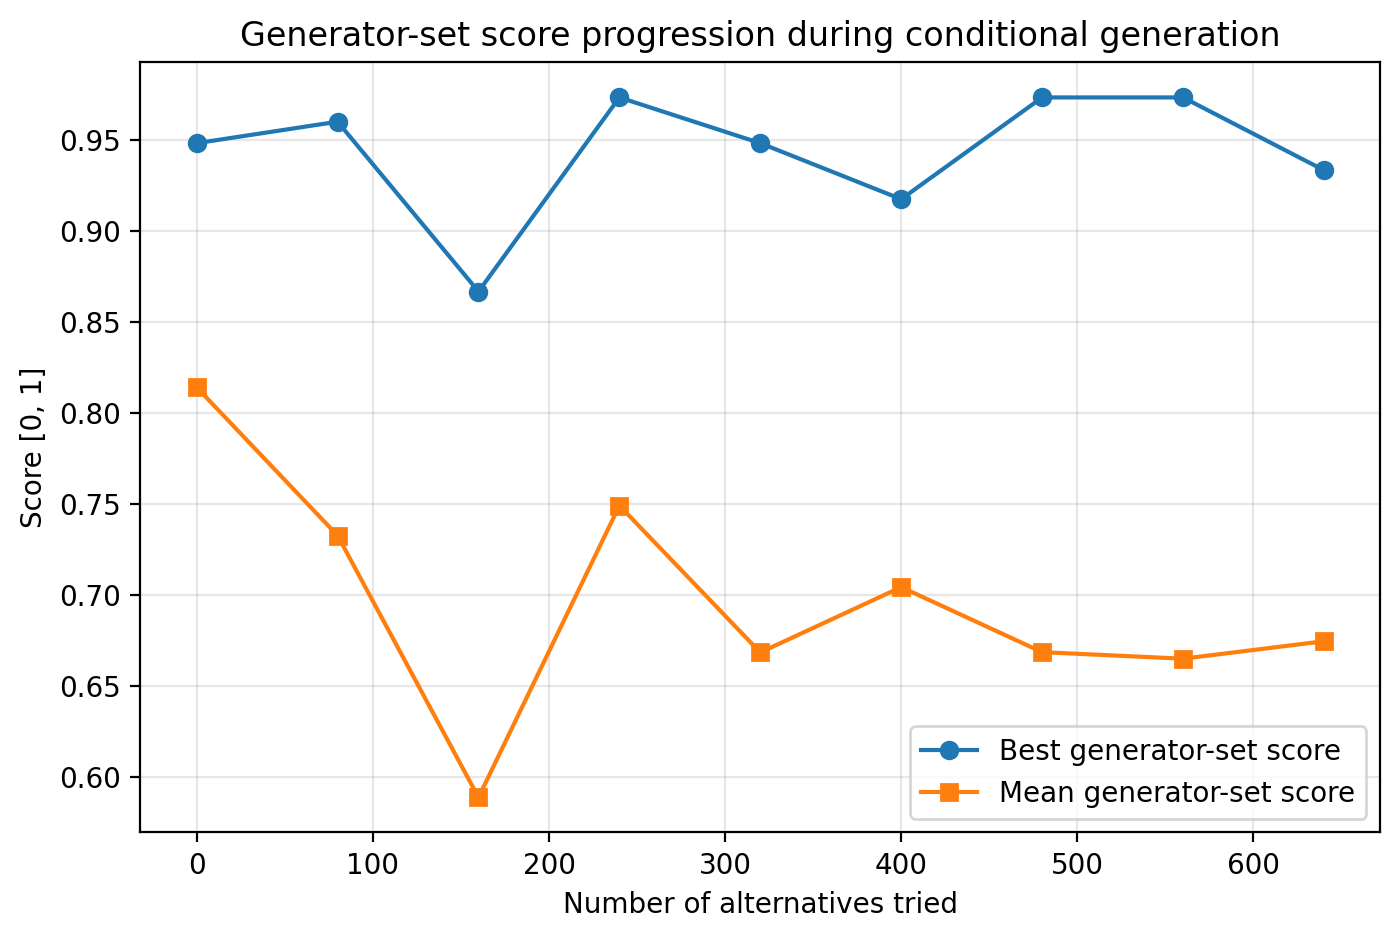

In [8]:
optimizer.plot_score_progress(history=history, show=True)

## 9) Inspect Final Results

Show:
- top molecules from the final generator set,
- top molecules globally across all generated candidates,
- benchmark comparison against best guardrailed example.



Best generator-set molecules (top by score):


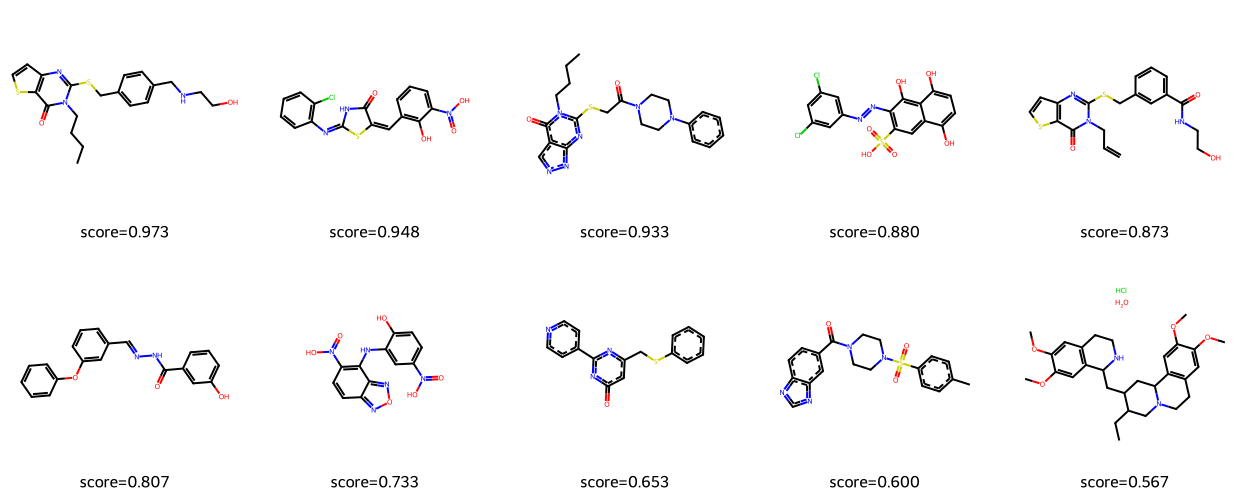

Top 10 best generator-set scores:
[0.9733 0.9482 0.9333 0.88   0.8733 0.8067 0.7333 0.6533 0.6    0.5667]
Top generated molecules from best-set evaluation:


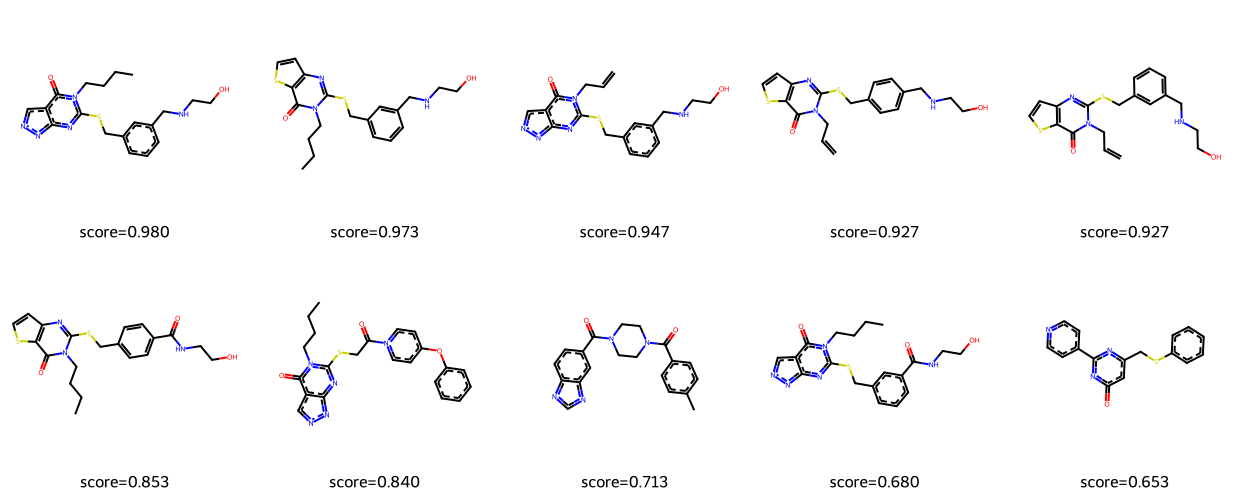

Top 10 generated-from-best-set scores:
[0.98   0.9733 0.9467 0.9267 0.9267 0.8533 0.84   0.7133 0.68   0.6533]


In [9]:
# 1) Best generator-set view (sorted by score).
best_set_scores = optimizer.score_graphs(best_generator_set_graphs)
best_set_order = np.argsort(-best_set_scores)
best_set_top_idx = best_set_order[:10]
best_set_top_graphs = [best_generator_set_graphs[i] for i in best_set_top_idx]
best_set_top_scores = best_set_scores[best_set_top_idx]

print('Best generator-set molecules (top by score):')
best_set_titles = [f"score={s:.3f}" for s in best_set_top_scores]
draw_molecules(best_set_top_graphs, n_graphs_per_line=5, titles=best_set_titles)
print('Top 10 best generator-set scores:')
print(np.round(best_set_top_scores, 4))

# 2) Top generated molecules from evaluating that best set.
best_generated_pool = GraphHashDeduper(parallel=True).fit_filter(best_generated_from_best_set)
best_generated_scores = optimizer.score_graphs(best_generated_pool)
best_generated_order = np.argsort(-best_generated_scores)
best_generated_top_idx = best_generated_order[:10]
best_generated_top_graphs = [best_generated_pool[i] for i in best_generated_top_idx]
best_generated_top_scores = best_generated_scores[best_generated_top_idx]

print('Top generated molecules from best-set evaluation:')
best_generated_titles = [f"score={s:.3f}" for s in best_generated_top_scores]
draw_molecules(best_generated_top_graphs, n_graphs_per_line=5, titles=best_generated_titles)
print('Top 10 generated-from-best-set scores:')
print(np.round(best_generated_top_scores, 4))

## 10) Standalone Generator Check

Fit `ConditionalAutoregressiveGenerator` on the best generator set, generate 10 new graphs, then score and visualize them.


Generated graphs: 9
Standalone generated molecules (top by score):


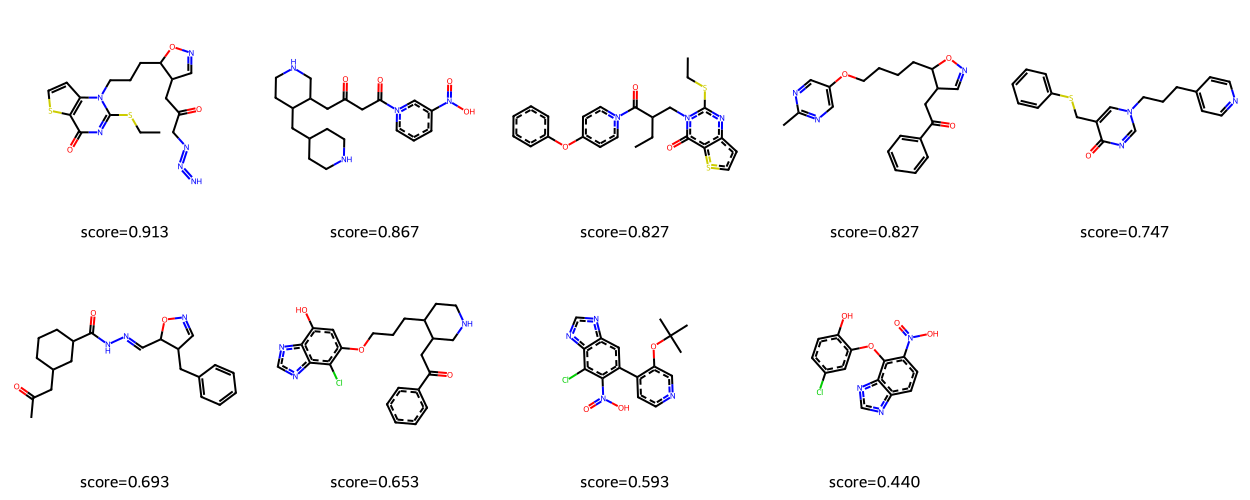

Top generated scores:
[0.9133 0.8667 0.8267 0.8267 0.7467 0.6933 0.6533 0.5933 0.44  ]


In [12]:
# Standalone generation from the best generator set.
standalone_generator = generator
standalone_generator.fit(
    best_generator_set_graphs,
    use_context_embedding=False,
    constraint_level=1,
    seed=SEED + 9782,
)

standalone_generated = standalone_generator.generate(
    n_samples=100,
    max_attempts=100,
)

standalone_generated = GraphHashDeduper(parallel=True).fit_filter(standalone_generated)
standalone_scores = np.asarray(score_function(standalone_generated), dtype=float)
standalone_order = np.argsort(-standalone_scores)
standalone_top_graphs = [standalone_generated[i] for i in standalone_order[:10]]
standalone_top_scores = standalone_scores[standalone_order[:10]]

print(f"Generated graphs: {len(standalone_generated)}")
if len(standalone_top_graphs) > 0:
    print('Standalone generated molecules (top by score):')
    standalone_titles = [f"score={s:.3f}" for s in standalone_top_scores]
    draw_molecules(standalone_top_graphs, n_graphs_per_line=5, titles=standalone_titles)
    print('Top generated scores:')
    print(np.round(standalone_top_scores, 4))
else:
    print('No valid standalone generations produced in this run.')



---


## 10) Top 10 Original Dataset Molecules by Score

Top 10 original dataset molecules by score:
[0.9482 0.9482 0.9174 0.9174 0.8451 0.8451 0.8067 0.7333 0.7067 0.7   ]


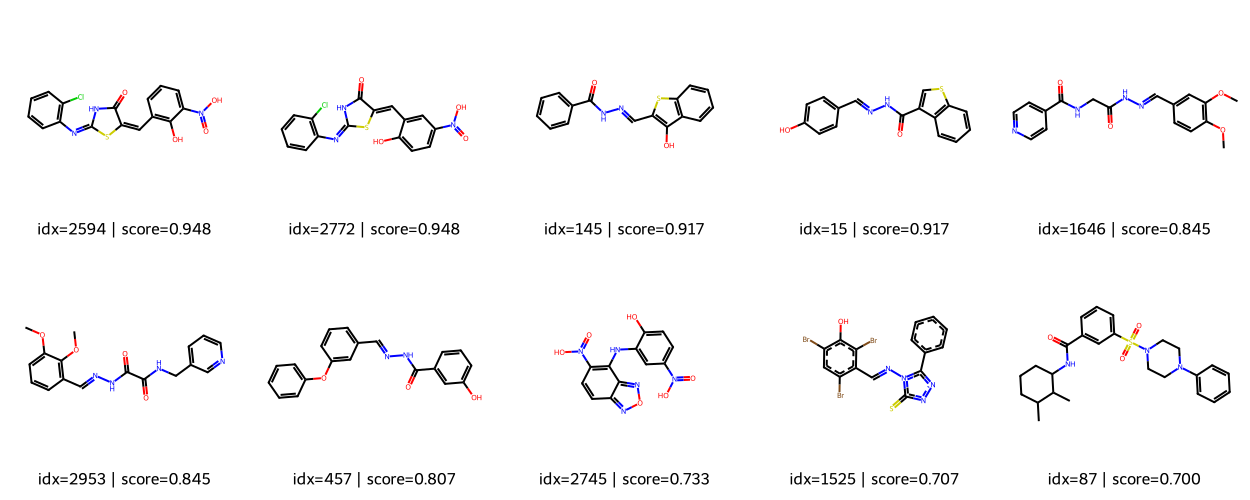

In [11]:
# Rank original dataset molecules by score and show top 10.
original_scores = np.asarray(score_function(graphs), dtype=float)
original_order = np.argsort(-original_scores)
original_top_idx = original_order[:10]
original_top_graphs = [graphs[i] for i in original_top_idx]
original_top_scores = original_scores[original_top_idx]

print('Top 10 original dataset molecules by score:')
print(np.round(original_top_scores, 4))

titles = [f"idx={i} | score={s:.3f}" for i, s in zip(original_top_idx, original_top_scores)]
draw_molecules(original_top_graphs, n_graphs_per_line=5, titles=titles)
